In [1]:
path = '/content/drive/MyDrive/컴퓨터비전_응용/data/wafer.jpg'

1. 색상에 대해서 히스토그램 그리기
2. 색상에 대한 마스크 적용하기

In [2]:
! pip install opencv-python

In [18]:
import os
import numpy as np
import cv2

import matplotlib.pyplot as plt

array([[[162, 162, 162],
        [126, 126, 126],
        [134, 134, 134],
        ...,
        [115, 115, 115],
        [110, 110, 110],
        [162, 162, 162]],

       [[139, 139, 139],
        [ 75,  75,  75],
        [ 74,  74,  74],
        ...,
        [  0,   0,   0],
        [ 12,  12,  12],
        [106, 106, 106]],

       [[120, 120, 120],
        [ 22,  22,  22],
        [ 21,  21,  21],
        ...,
        [  0,   0,   0],
        [  5,   5,   5],
        [112, 112, 112]],

       ...,

       [[117, 117, 117],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  1,   1,   1],
        [  1,   1,   1],
        [114, 114, 114]],

       [[108, 108, 108],
        [ 11,  11,  11],
        [  2,   2,   2],
        ...,
        [  1,   1,   1],
        [  6,   6,   6],
        [109, 109, 109]],

       [[158, 158, 158],
        [109, 109, 109],
        [106, 106, 106],
        ...,
        [114, 114, 114],
        [108, 108, 108],
        [161, 161, 161]]], dtype=uint8)
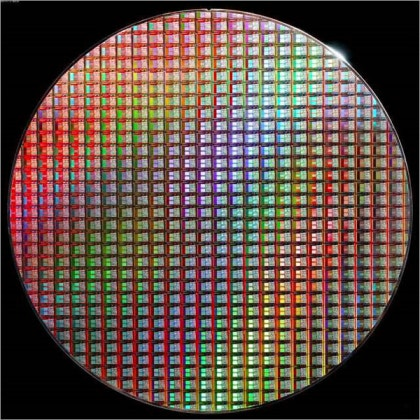

In [26]:
cv2.imread(path)

In [27]:
src = cv2.imread(path)

array([[[162, 162, 162],
        [126, 126, 126],
        [134, 134, 134],
        ...,
        [115, 115, 115],
        [110, 110, 110],
        [162, 162, 162]],

       [[139, 139, 139],
        [ 75,  75,  75],
        [ 74,  74,  74],
        ...,
        [  0,   0,   0],
        [ 12,  12,  12],
        [106, 106, 106]],

       [[120, 120, 120],
        [ 22,  22,  22],
        [ 21,  21,  21],
        ...,
        [  0,   0,   0],
        [  5,   5,   5],
        [112, 112, 112]],

       ...,

       [[117, 117, 117],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  1,   1,   1],
        [  1,   1,   1],
        [114, 114, 114]],

       [[108, 108, 108],
        [ 11,  11,  11],
        [  2,   2,   2],
        ...,
        [  1,   1,   1],
        [  6,   6,   6],
        [109, 109, 109]],

       [[158, 158, 158],
        [109, 109, 109],
        [106, 106, 106],
        ...,
        [114, 114, 114],
        [108, 108, 108],
        [161, 161, 161]]], dtype=uint8)
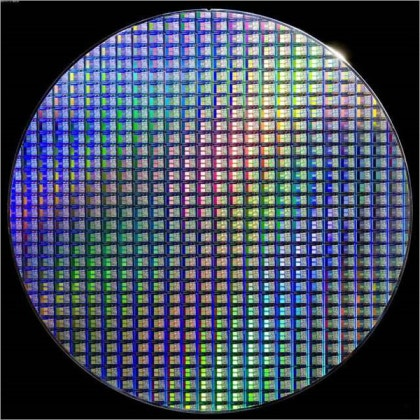

In [28]:
cv2.cvtColor(src, cv2.COLOR_BGR2RGB)

array([[162, 126, 134, ..., 115, 110, 162],
       [139,  75,  74, ...,   0,  12, 106],
       [120,  22,  21, ...,   0,   5, 112],
       ...,
       [117,   0,   0, ...,   1,   1, 114],
       [108,  11,   2, ...,   1,   6, 109],
       [158, 109, 106, ..., 114, 108, 161]], dtype=uint8)
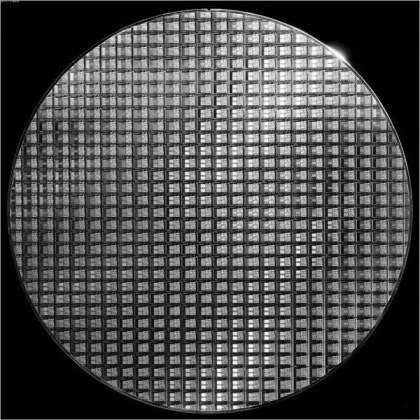

In [29]:
cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
# grayscale

array([[162, 126, 134, ..., 115, 110, 162],
       [139,  75,  74, ...,   0,  12, 106],
       [120,  22,  21, ...,   0,   5, 112],
       ...,
       [117,   0,   0, ...,   1,   1, 114],
       [108,  11,   2, ...,   1,   6, 109],
       [158, 109, 106, ..., 114, 108, 161]], dtype=uint8)
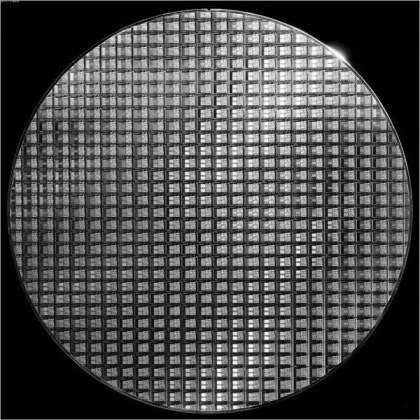

In [30]:
dst = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)

dst

In [32]:
# cv2.calcHist() 히스토그램 계산 함수
hist = cv2.calcHist([dst], [0], None, [256], [0, 256])

# cv2 이용해 히스토그램 계산
# 0번 채널
# None : 마스크 설정이 None(전체 이미지 사용)
# [256] : bin(계급구간) 개수 (0-255, 총 256개 구간) 밝기>> 히스토그램의 x 범위
# [0, 256] : 픽셀의 범위(0-255) >> 히스토그램의 y 범위

hist[250]
# 밝기 값이 250인 픽셀의 개수

array([30.], dtype=float32)

In [34]:
print(hist[0])
print(hist[255])
# 이 이미지는 검정색이 훨씬 많다.
# >> 보정해야 한다면 명도를 조정해야 한다.
# >> 즉, 밝기를 높이고, 컬러 사진일 경우 채도를 높이는 작업을 해야한다.

[10619.]
[1.]


In [37]:
hist_color = cv2.calcHist([src], [0], None, [256], [0, 256])
print(hist_color[0])
print(hist_color[255])

[11868.]
[227.]


In [40]:
hist[0,0]
# 행렬의 가장 첫번째 값

np.float32(10619.0)

In [45]:
# x 좌표(pixel 값 범위 0-255)
# channels : 분석할 채널 (grayscale [0] 지정)
# histSize : 히스토그램 구간 수 (0-255: 총 256개 구간)
# histRange :pixel 값 범위(0-255)

hist_size = [256]
hist_range = [0, 256] # 0-255

# opencv 함수 활용
# cv2.calcHist(image, channel number, None, x가 몇 개로 나누어야 하는지, x 범위)
hist = cv2.calcHist([src], [0], None, hist_size, hist_range)
# hist

In [49]:
# hist
# 어느 픽셀이 제일 많이 있는가 (최대값 카운트)
# 최대값 의미 : histMax 기준으로 다른 모든 그래프를 그린다.
hist_max = np.max(hist) # np.float32(24815.0)


In [50]:
# 컴퓨터 입장에서 생각
# y값이 클수록 아래로, 작을수록 위로 (좌상단 좌표가 0,0)
# 컴퓨터는 y가 아애로 늘어난다. (y축이 뒤집혀 있다.)
# 막대를 위로 올리려면, 전체 높이(100)이라면, 전체 높이에서 빼야 한다.

In [54]:
# 1단계 : 현재 밝기 값의 픽셀 개수
x = 0   # 완전 검은색
hist[x, 0]  # np.float32(11868.0) >> 픽셀 11868개

# hist = cv2.calcHist([src], [0], None, hist_size, hist_range)
# hist 미리 계산해 둔 히스토그램 표
# hist[0, 0] 0번(검은색) 인덱스에 픽셀 개수가 몇 개? 11868개 있다.

np.float32(11868.0)

In [56]:
# 2단계 : 최대값 대비 비율 (0-1 사이)
# 3단계 : %로 변환(백분율, 0-100 사이)
hist[x,0] * 100 / hist_max

np.float32(47.825912)

In [58]:
# 4단계 : 정수로 변환
int(hist[x,0] * 100 / hist_max)

47

In [60]:
# 5단계 : y 좌표 계산(아래에서 위)
# 100에서 빼는 이유?
# 컴퓨터는 y축이 뒤집혀 있다.

100 - int(hist[x,0] * 100 / hist_max)   # 53

53

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
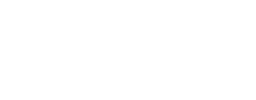

In [63]:
# 그래프를 그릴 도화지
# 255(흰색) 채워진 100*256 도화지 준비
# 가로 256, 세로 100칸 행렬(이미지)

np.full((100, 256), 255, dtype=np.uint8)

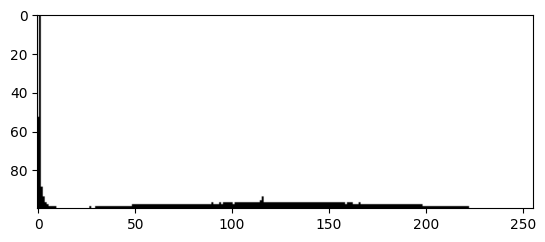

In [66]:
img_bg = np.full((100, 256), 255, dtype=np.uint8)

for x in range(256):
    # 시작점 pt1
    pt1 = (x, 100)
    # 컴퓨터는 y축이 뒤집혀 있다. 높이가 100인 경우, 디지털 100 = 사람 생각하는 입장에서 0
    # 도화지 맨 아래 바닥라인(y=100) 그리기 시작

    # 끝점 pt2
    pt2 = (x, 100 - int(hist[x, 0]*100/hist_max))

    # cv2.line(image, 시작점, 끝점, 색상)
    cv2.line(img_bg, pt1, pt2, 0)

plt.imshow(img_bg, cmap='gray')
plt.show()

pt= (x, 100) 의미


- (x, 100) = (가로 위치, 세로 위치)


- x = 0   >>   (0, 100) (밝기 0 (왼쪽 끝) 아래쪽)
- x = 50  >>  (50, 100) (밝기 50 위치에서 아래쪽)
- x = 100 >> (100, 100) (밝기 100 위치에서 아래쪽)


일반적으로 히스토그램 (밝기, 개수) 형태임


가로축(x축) : 픽셀 밝기 값 위치
- x=0 (아주 어두운 픽셀)
- x= 128 (중간 밝기)
- x = 255 (아주 밝은 픽셀)


세로축(y축) : 픽셀의 개수


In [73]:
# plt.plot(hist)
# plt.show()

### 마스크(색상 마스크) : ROI(Resion Of Interesting, 관심영역)

array([[[162, 162, 162],
        [126, 126, 126],
        [134, 134, 134],
        ...,
        [115, 115, 115],
        [110, 110, 110],
        [162, 162, 162]],

       [[139, 139, 139],
        [ 75,  75,  75],
        [ 74,  74,  74],
        ...,
        [  0,   0,   0],
        [ 12,  12,  12],
        [106, 106, 106]],

       [[120, 120, 120],
        [ 22,  22,  22],
        [ 21,  21,  21],
        ...,
        [  0,   0,   0],
        [  5,   5,   5],
        [112, 112, 112]],

       ...,

       [[117, 117, 117],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  1,   1,   1],
        [  1,   1,   1],
        [114, 114, 114]],

       [[108, 108, 108],
        [ 11,  11,  11],
        [  2,   2,   2],
        ...,
        [  1,   1,   1],
        [  6,   6,   6],
        [109, 109, 109]],

       [[158, 158, 158],
        [109, 109, 109],
        [106, 106, 106],
        ...,
        [114, 114, 114],
        [108, 108, 108],
        [161, 161, 161]]], dtype=uint8)
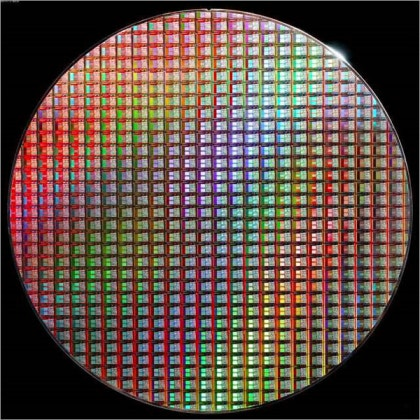

In [75]:
# 색공간(HSV)

cv2.imread(path)

array([[[162, 162, 162],
        [126, 126, 126],
        [134, 134, 134],
        ...,
        [115, 115, 115],
        [110, 110, 110],
        [162, 162, 162]],

       [[139, 139, 139],
        [ 75,  75,  75],
        [ 74,  74,  74],
        ...,
        [  0,   0,   0],
        [ 12,  12,  12],
        [106, 106, 106]],

       [[120, 120, 120],
        [ 22,  22,  22],
        [ 21,  21,  21],
        ...,
        [  0,   0,   0],
        [  5,   5,   5],
        [112, 112, 112]],

       ...,

       [[117, 117, 117],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  1,   1,   1],
        [  1,   1,   1],
        [114, 114, 114]],

       [[108, 108, 108],
        [ 11,  11,  11],
        [  2,   2,   2],
        ...,
        [  1,   1,   1],
        [  6,   6,   6],
        [109, 109, 109]],

       [[158, 158, 158],
        [109, 109, 109],
        [106, 106, 106],
        ...,
        [114, 114, 114],
        [108, 108, 108],
        [161, 161, 161]]], dtype=uint8)
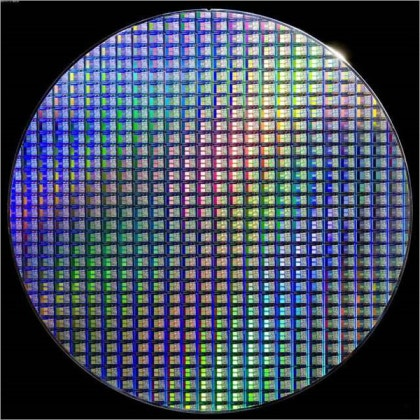

In [77]:
image = cv2.imread(path)
cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

array([[[  0,   0, 162],
        [  0,   0, 126],
        [  0,   0, 134],
        ...,
        [  0,   0, 115],
        [  0,   0, 110],
        [  0,   0, 162]],

       [[  0,   0, 139],
        [  0,   0,  75],
        [  0,   0,  74],
        ...,
        [  0,   0,   0],
        [  0,   0,  12],
        [  0,   0, 106]],

       [[  0,   0, 120],
        [  0,   0,  22],
        [  0,   0,  21],
        ...,
        [  0,   0,   0],
        [  0,   0,   5],
        [  0,   0, 112]],

       ...,

       [[  0,   0, 117],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   1],
        [  0,   0,   1],
        [  0,   0, 114]],

       [[  0,   0, 108],
        [  0,   0,  11],
        [  0,   0,   2],
        ...,
        [  0,   0,   1],
        [  0,   0,   6],
        [  0,   0, 109]],

       [[  0,   0, 158],
        [  0,   0, 109],
        [  0,   0, 106],
        ...,
        [  0,   0, 114],
        [  0,   0, 108],
        [  0,   0, 161]]], dtype=uint8)
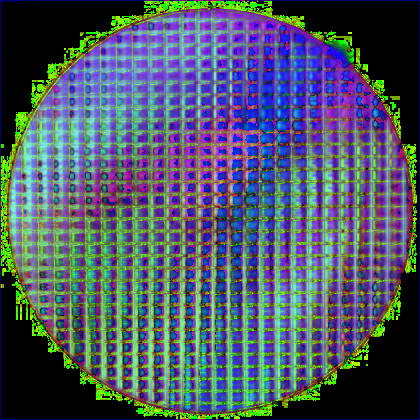

In [82]:
cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
# HSV(Hue, Saturation, Value / 색, 채도, 명도) >> 명도 중요
# >> 색상 분리하기 위해

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
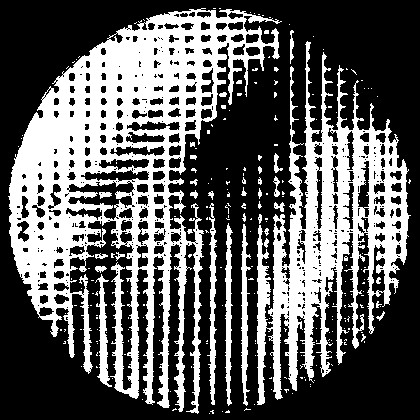

In [88]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
# 예제) 파란색만 추출하고 싶어요
# 파란색 범위(2개) 내가 지정
lower_blue = np.array([90, 50, 50])
high_blue = np.array([130, 255, 255])

# hue (색상) 0-179(180구간) 90-130 파란색
# saturation (채도) 0-255 (일반적으로 50 이상을 선택)
# value (명도) 0-255 (일반적으로 50 이상을 선택)

# 마스크 색상
cv2.inRange(hsv, lower_blue, high_blue)

# 내가 원하는특정 색상(파랑) 영역만 추출
# >> 3차원 공간의 임계값 처리

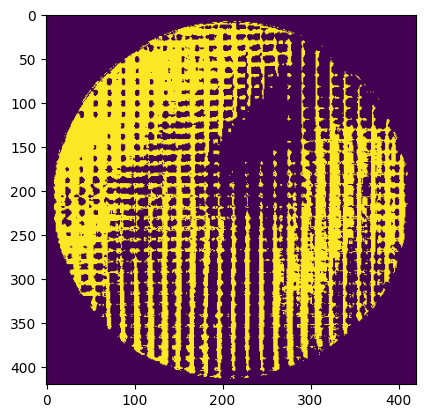

In [90]:
mask = cv2.inRange(hsv, lower_blue, high_blue)
# lower-high 사이에 있는 값은 흰색(255)으로 바뀌고, 범위에 속하지 않는 픽셀은 0으로 젼함. 검은색(0) >> 분류가 명확해!
# mask 역할 : 필터링
plt.imshow(mask)
plt.show()

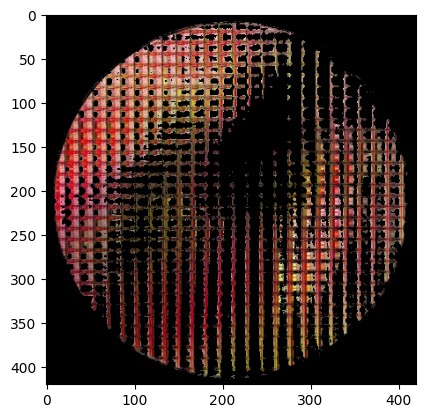

In [93]:
# AND 연산자
# (MASK) 해당하는 흰색 부분만 남기기
result = cv2.bitwise_and(image, image, mask=mask)

plt.imshow(result)
plt.show()

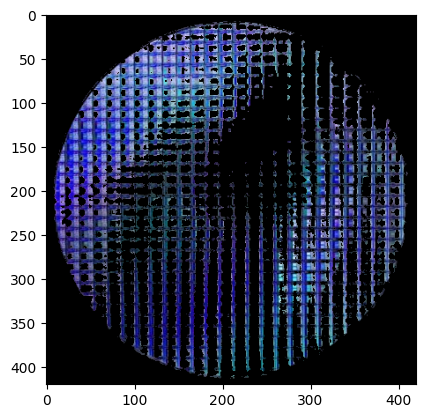

In [94]:
result = cv2.bitwise_and(image, image, mask=mask)
dst = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.imshow(dst)
plt.show()

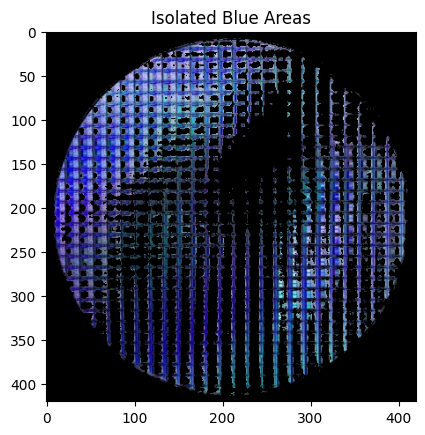

In [97]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 이미지 로드
image = cv2.imread(path)
src = image.copy()
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# hsv에서 파란색 영역 정의
lower_blue = np.array([90, 50, 50])
high_blue = np.array([130, 255, 255])

# mask 생성(특정영역 추출)
mask = cv2.inRange(hsv, lower_blue, high_blue)

# 원본 이미지에 적용
dst = cv2.bitwise_and(src, src, mask=mask)

# RGB로 전환
dst_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)

plt.imshow(dst_rgb)
plt.title('Isolated Blue Areas')
plt.show()
# matplotlib로 확인하면, 색상있는 이미지 확인 가능